In [160]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# 1. Data Wrangling

In [161]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape,"\n")
print(csv_data.dtypes,"\n")
csv_data.head()

CSV dimensions:  (144, 2) 

Month          object
#Passengers     int64
dtype: object 



,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [162]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.set_index('date', inplace=True)

# Set Frequency to avoid error when scoring ARIMA later
csv_data.index = pd.DatetimeIndex(csv_data.index.values, freq='MS')

csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [163]:
# Check if the file exists and remove it
filename = 'clean_passengers.pkl'
if os.path.isfile(filename):
    os.remove(filename)
csv_data.to_pickle(filename)


# If running on Google colab:
# from google.colab import files
# files.download(filename)


print(f"csv_data saved as '{filename}'")

csv_data saved as 'clean_passengers.pkl'


# 2. Data Exploration

In [164]:
# Read processed clean data (from GitHub):
filename = 'clean_passengers.pkl'

# # Only if using Google colab
# if os.path.isfile(filename):
#     os.remove(filename)
# !wget https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap3_AirPassengers/2_DataWrangling/clean_passengers.pkl

csv_Data = pd.read_pickle(filename)
csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 2.1 Check for missing/duplicate data

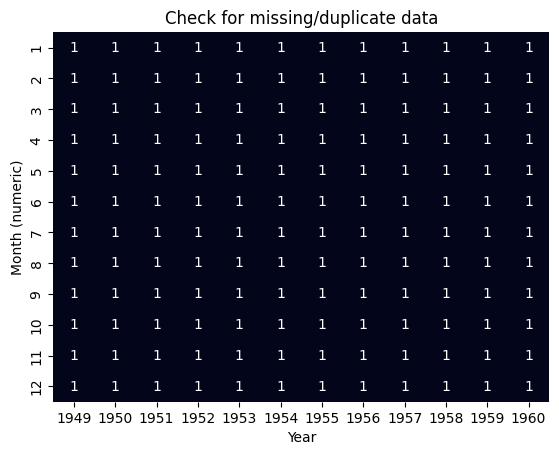

In [6]:
heat_dt1 = csv_data.copy().reset_index(names="date").\
            groupby('date', as_index=False).count().\
            rename(columns={'n_passengers':'N'})

heat_dt1["status"] = heat_dt1['N'].apply(lambda x: 1 if x==1 and x is not None else 2 if x>1 and x is not None else 0)
heat_dt1["month"]  = heat_dt1['date'].dt.month
heat_dt1["year"]   = heat_dt1['date'].dt.year

heat_dt2 = pd.DataFrame(heat_dt1, columns=['status','month','year']).set_index(['month','year']).\
            pivot_table(index='month', columns='year', values='status')

# heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)
plt. title("Check for missing/duplicate data")
plt.xlabel("Year")
plt.ylabel("Month (numeric)")
plt.show()

Legend for annotation:
*    0 = Data is absent (Missing data; Gaps in time series trend)
*    1 = Data present for the month
*    2 = Duplicate data identified

**No missing or dupliate data observed in data!**

## 2.2 Check for outliers

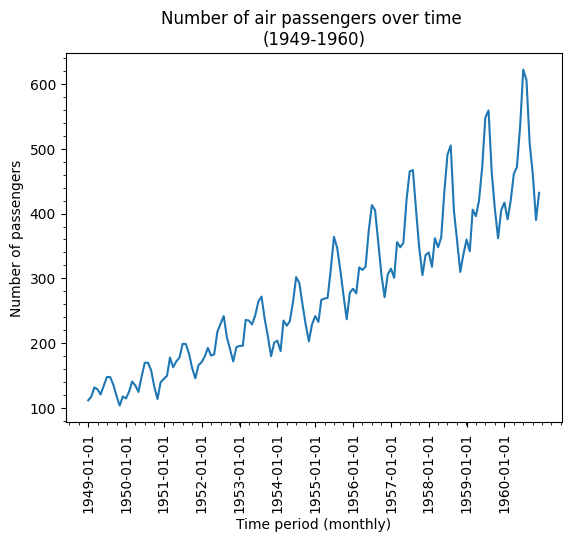

In [100]:

sns.lineplot(data=csv_data, x=csv_data.index, y="n_passengers")
# plt.vlines(x=[], ymin=0, ymax=100)
plt.xlabel("Time period (monthly)")
plt.ylabel("Number of passengers")
plt.title("Number of air passengers over time \n(1949-1960)")
plt.minorticks_on()
plt.xticks([i.strftime("%Y-%m") for i in csv_data.index if i.strftime("%m")=="01"], rotation=90)
plt.show()


**No outiers** are seen in the time series.
Seasonality is evident in the trend (on a yearly basis), with an upward growing trend. The data is in definite need for differencing

## 2.3. Decomposition

Is it an Additive or Multiplicative model?

<Figure size 1000x700 with 0 Axes>

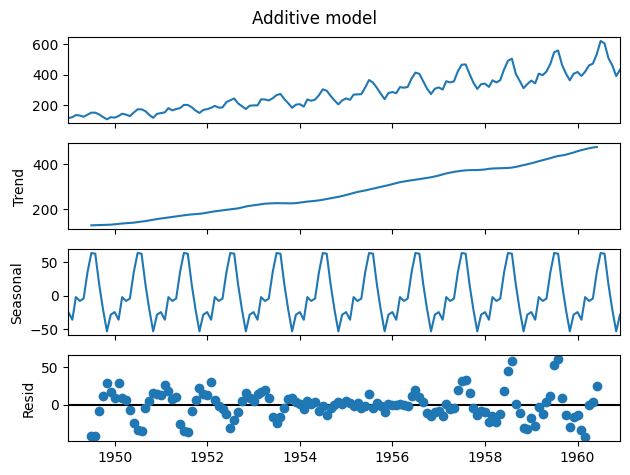

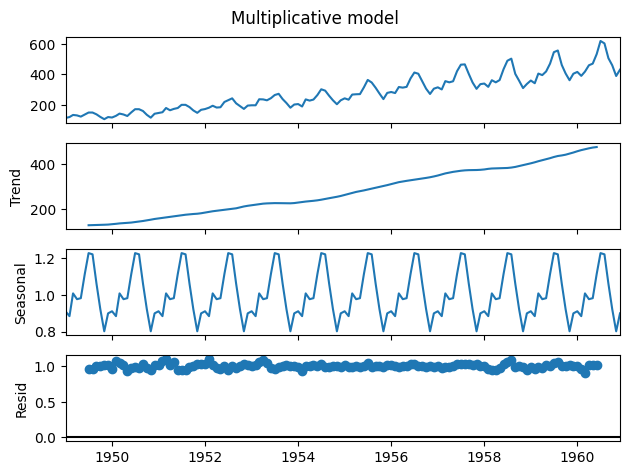

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
plt.figure(figsize=(10, 7))
decomp1 = seasonal_decompose(csv_data['n_passengers'], period=12, model='additive')
add_fig = decomp1.plot()
for ax in add_fig.axes:
    ax.set_title("")
add_fig.suptitle("Additive model")
plt.xlabel("")
plt.show()

decomp2 = seasonal_decompose(csv_data['n_passengers'], period=12, model='multiplicative')
mul_fig = decomp2.plot()
for ax in mul_fig.axes:
    ax.set_title("")
mul_fig.suptitle("Multiplicative model")
plt.show()

The additive models still leaves behind some trends in the residuals after decomposition. Thus **multiplicative model** was chosen for decomposition!

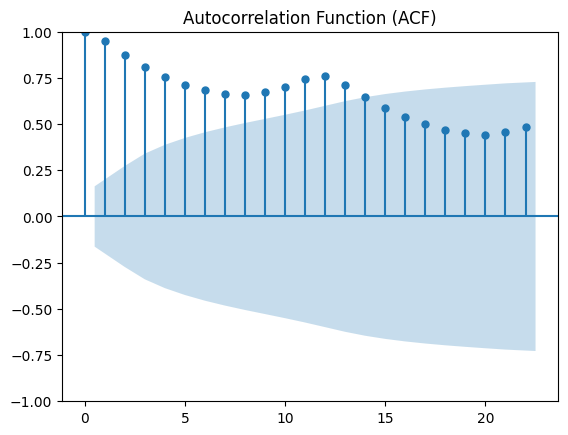

In [9]:
plot_acf(csv_data)
plt.title("Autocorrelation Function (ACF)")
plt.show()

A gradual decline is seen, indicating a **long-term dependency** (i.e. past values have a prolonged effect). Also there are many significant values observed suggesting the data is **non-stationary**.

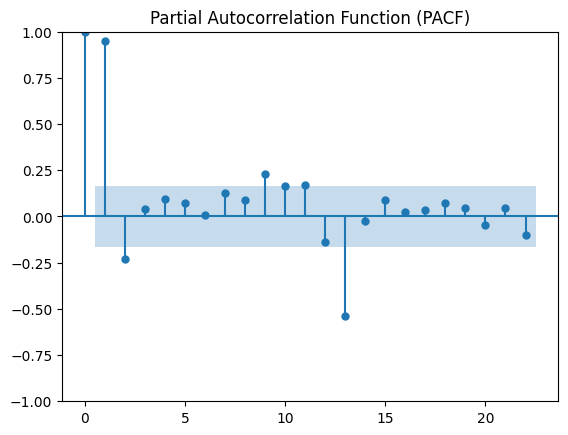

In [10]:
plot_pacf(csv_data)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

The data likely requires a lag-2 or AR(2) model (i.e. p=2).
Also, the PACF has isolated significant values at certain lags (1, 2, 9 & 13), it suggests those lags are important predictors for the current value.

# 3. Modelling

In [188]:
## Load packages required for modelling
import warnings
from sklearn.metrics import mean_squared_error
from joblib import dump, load

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from pmdarima import auto_arima

## LSTM packages
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.metrics import RootMeanSquaredError

In [172]:
# Split data for Training & Testing:

Split_percentage = 0.7
split_at_n = int(np.floor(Split_percentage * csv_data.shape[0]))

train, test = csv_data[:split_at_n], csv_data[split_at_n:]

Since there are no additional features, pre-processing is very straightforward

## 3.1 ARIMA

### 3.1.1 ADF Test

In [13]:
def differencing(x, d=0, s=1):
  if d>0:
    y = x.diff(s).dropna()
    return differencing(y, d-1)
  else:
    return x

d_data = pd.DataFrame({'ADF_statistic':[],
                       'p_value':[],
                       'Crit_5%':[],
                       'AIC':[]})

for d in range(3):
  diff_data = differencing(train, d)
  x1, x2, x3, x4, x5, x6 = adfuller(diff_data['n_passengers'])
  d_data.loc[d] = [x1, x2, x5['5%'], x6]
  # print(f"d({d}) = {d_data.loc[d]} \n")
diff_data = differencing(train, 2)

print(d_data)

   ADF_statistic       p_value   Crit_5%         AIC
0       1.509804  9.975601e-01 -2.895382  654.045173
1      -2.180602  2.133612e-01 -2.895784  640.650610
2     -12.177952  1.372387e-22 -2.895784  637.955371


1st order differencing craetes a weakly stationary time series, while a 2nd order differencing craetes a strongly stationary time series. Thus d=2 is selected for ARIMA

3.1.1 Find the best order (= p, d, q)

Knowing a 2nd order differencing (d=2) is required, we try to find the ideal values for p & q:

In [14]:
warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_arima(dt, arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS")
    arima_fit  = arima.fit()

    ## Scoring method (AIC or MSE):
    res = mean_squared_error(test, arima_fit.forecast(steps=len(test)) )
    # res = arima_fit.aic
  except:
    res = np.inf
  return res

# evaluate_arima(train, (0, 0, 2))
score_list = []
order_list = []
for p in range(4):
  for d in [2]:
    for q in range(4):
      order_result = round(evaluate_arima(diff_data, (p, d, q)), 3);
      if order_result != np.inf:
        score_list.append(order_result)
        order_list.append((p, d, q))
        print(f"ARIMA({p}, {d}, {q}) = {order_result}")

warnings.resetwarnings()

ARIMA(0, 2, 0) = 14870146.068
ARIMA(1, 2, 0) = 2604637.325
ARIMA(1, 2, 1) = 202527.958
ARIMA(1, 2, 3) = 185455.243
ARIMA(2, 2, 0) = 569307.669
ARIMA(2, 2, 1) = 192656.567
ARIMA(3, 2, 0) = 579848.473
ARIMA(3, 2, 1) = 192012.066


Tried evaluating ARIMA model using:
*  AIC: It generates a very simplistic model (but not efficient/accurate)
*  MSE: Found to be a better scoring method, which forcasts values much better (w.r.t. AIC/BIC at least)

In [15]:
# # Alternate method for find the best order (hyperparameter testing)
# !pip install pmdarima
# import pmdarima

# # Fit Auto ARIMA to find optimal p, d, q
# auto_model = auto_arima(train['n_passengers'], m=12, seasonal=True, stepwise=False, trace=True)

# # Print optimal parameters
# print(auto_model.summary())


In [16]:
summary_dict = dict(zip(order_list, score_list))

min_value = min(summary_dict.values())
best_arima_order, best_arima_score = [(key,value) for key, value in summary_dict.items() if value == min_value][0]

print(f"Best ARIMA params (p, d, q) = {best_arima_order}. \n Score = {best_arima_score}")

Best ARIMA params (p, d, q) = (1, 2, 3). 
 Score = 185455.243


In [17]:
## Impact of 'trend'-parameter:
def evaluate_arima_trend(dt, trend, arima_order=best_arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS", trend=trend)
    arima_fit  = arima.fit()
    res = mean_squared_error(test, arima_fit.forecast(steps=len(test)) )
    # res = arima_fit.aic
  except:
    res = np.inf
  return res

for trend in ['n','c','t','ct']:
  trend_result = evaluate_arima_trend(diff_data, trend=trend)
  # if trend_result != np.inf:
  print(f"ARIMA('{trend}') = {trend_result}")

ARIMA('n') = 185455.24276591337
ARIMA('c') = inf
ARIMA('t') = inf
ARIMA('ct') = inf


By default, ARIMA chooses trend='n' (No trend), since differencing is required for the data. So this test plays no effect on hyperparameter testing.

In [19]:
# Fit ARIMA model (p, d, q) parameters
arima_model = ARIMA(train, order = best_arima_order)
arima_fit = arima_model.fit()

# Print summary of the model
print(arima_fit.summary())

# Forecast next 10 steps
arima_pred = pd.DataFrame({"n_passengers" : arima_fit.forecast(steps=len(test))},
                         index = test.index)

# print("Forecast:", arima_pred)
# arima_pred.index

                               SARIMAX Results                                
Dep. Variable:           n_passengers   No. Observations:                  100
Model:                 ARIMA(1, 2, 3)   Log Likelihood                -444.097
Date:                Wed, 21 May 2025   AIC                            898.195
Time:                        19:38:43   BIC                            911.119
Sample:                    01-01-1949   HQIC                           903.422
                         - 04-01-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6795      0.161     -4.215      0.000      -0.995      -0.364
ma.L1          0.0260     23.614      0.001      0.999     -46.257      46.309
ma.L2         -0.9428     24.301     -0.039      0.9

(144, 1) (144, 1)


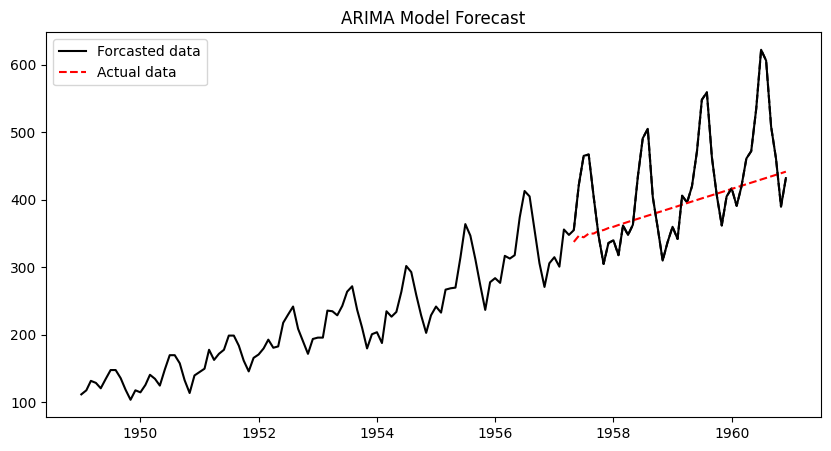

In [20]:
forecast_dt = pd.concat([train, arima_pred])
original_data = csv_data.copy()

print(forecast_dt.shape, original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data", color="black")
plt.plot(arima_pred.index, arima_pred["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
plt.plot(test.index, test["n_passengers"], label="Forcasted Data", linestyle="--", color="black")
plt.legend(["Forcasted data", "Actual data"])
plt.title("ARIMA Model Forecast")
plt.show()

ARIMA does not take seasonality in consideration. So even though it can suitably predict the growing trending, it is not a reliable model for forcasting this data.

In [21]:
# Check if the file exists and remove it
filename = './models/best_ARIMA.joblib'

if not os.path.isdir('models'):
    !mkdir models;
if os.path.isfile(filename):
    os.remove(filename)
dump(arima_fit, filename)


# # ONLY IF running on Google colab:
# from google.colab import files
# files.download(filename)


print(f"ARIMA model saved as '{filename}'")

ARIMA model saved as './models/best_ARIMA.joblib'


In [22]:
# Check if the file exists and remove it
filename = './models/best_ARIMA.joblib'


# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/models/best_ARIMA.joblib


arima_model = load(filename)

## 3.2 SARIMA

Continuing upon the ADF test conducted for ARIMA, we identify D (seasonal differencing) param for SARIMA.

In [59]:
def differencing(x, d=0, s=1):
  if d>0:
    y = x.diff(s).dropna()
    return differencing(y, d-1)
  else:
    return x

D_data = pd.DataFrame({'ADF_statistic':[],
                       'p_value':[],
                       'Crit_5%':[],
                       'AIC':[]})

for D in range(3):
  sdiff_data = differencing(diff_data, D, 12)
  x1, x2, x3, x4, x5, x6 = adfuller(sdiff_data['n_passengers'])
  D_data.loc[D] = [x1, x2, x5['5%'], x6]
  # print(f"D({D}) = {d_data.loc[D]} \n")
sdiff_data = differencing(diff_data, 1, 12)

print(D_data)

   ADF_statistic       p_value   Crit_5%         AIC
0     -12.177952  1.372387e-22 -2.895784  637.955371
1      -6.264446  4.146871e-08 -2.899375  564.625995
2      -6.827028  1.936135e-09 -2.900925  575.303337


In [60]:
### Based on results of ADF test:
d = 2 ## Non-seasonal differencing
D = 0 ## Seasonal differencing

### Since data is monthly seies:
m = 12

No seasonal differencing is required since data is already stationary (i.e. D=0)

In [61]:
warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_sarima(dt, order, s_order):
  try:
    sarima = SARIMAX(dt, order=order, seasonal_order=s_order)
    sarima_fit  = sarima.fit()

    ## Scoring method (AIC or MSE):
    res = mean_squared_error(test, sarima_fit.forecast(steps=len(test)) )
    res = sarima_fit.aic
  except:
    res = np.inf
    return res

# print(evaluate_sarima(train, (1, 2, 1), (2, 0, 1, 12)))
score_list = []
order_list = []
for p in range(4):
    for q in range(4):
      for P in range(4):
        for Q in range(4):
          order_result = evaluate_sarima(train, (p, d, q), (P, D, Q, m))
          if order_result != np.inf:
            score_list.append(order_result)
            order_list.append([(p, d, q), (P, D, Q, m)])
            print(f"SARIMA({p}, {d}, {q}, {P}, {D}, {Q}, {m}) = {order_result}")

warnings.resetwarnings()

SARIMA(0, 2, 0, 0, 0, 0, 12) = None
SARIMA(0, 2, 0, 0, 0, 1, 12) = None
SARIMA(0, 2, 0, 1, 0, 0, 12) = None
SARIMA(0, 2, 1, 0, 0, 0, 12) = None
SARIMA(0, 2, 1, 0, 0, 1, 12) = None
SARIMA(0, 2, 1, 1, 0, 0, 12) = None
SARIMA(0, 2, 2, 0, 0, 0, 12) = None
SARIMA(0, 2, 2, 0, 0, 1, 12) = None
SARIMA(0, 2, 2, 1, 0, 0, 12) = None
SARIMA(0, 2, 3, 0, 0, 0, 12) = None
SARIMA(0, 2, 3, 0, 0, 1, 12) = None
SARIMA(0, 2, 3, 1, 0, 0, 12) = None
SARIMA(1, 2, 0, 0, 0, 0, 12) = None
SARIMA(1, 2, 0, 0, 0, 1, 12) = None
SARIMA(1, 2, 0, 1, 0, 0, 12) = None
SARIMA(1, 2, 1, 0, 0, 0, 12) = None
SARIMA(1, 2, 1, 0, 0, 1, 12) = None
SARIMA(1, 2, 1, 1, 0, 0, 12) = None
SARIMA(1, 2, 2, 0, 0, 0, 12) = None
SARIMA(1, 2, 2, 0, 0, 1, 12) = None
SARIMA(1, 2, 2, 1, 0, 0, 12) = None
SARIMA(1, 2, 3, 0, 0, 0, 12) = None
SARIMA(1, 2, 3, 0, 0, 1, 12) = None
SARIMA(2, 2, 0, 0, 0, 0, 12) = None
SARIMA(2, 2, 0, 0, 0, 1, 12) = None
SARIMA(2, 2, 0, 1, 0, 0, 12) = None
SARIMA(2, 2, 1, 0, 0, 0, 12) = None
SARIMA(2, 2, 1, 1, 0, 0, 12)

In [ ]:
import pmdarima as pm

# Auto-SARIMA with seasonality
sarima_fit = pm.auto_arima(train['n_passengers'], seasonal=True, m=12, stepwise=False, trace=True)

print(model.summary())


In [ ]:
# Forecast on test data
sarima_pred = pd.DataFrame({"n_passengers" : sarima_fit.predict(n_periods=len(test))},
                           index = test.index)

# Compute MSE
mse = mean_squared_error(test, sarima_pred)
print("MSE for selected SARIMA model:", mse)

In [ ]:
forecast_dt = pd.concat([train, sarima_pred])
original_data = csv_data.copy()

print(forecast_dt.shape, original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data", color="black")
plt.plot(sarima_pred.index, sarima_pred["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
# plt.plot(test.index, test["n_passengers"], label="Forcasted Data", linestyle="--", color="black")
plt.legend(["Forcasted data", "Actual data"])
plt.title("ARIMA Model Forecast")
plt.show()

In [ ]:
 # Check if the file exists and remove it
filename = './models/best_SARIMA.joblib'

if not os.path.isdir('models'):
    !mkdir models;
if os.path.isfile(filename):
    os.remove(filename)
dump(sarima_fit, filename)


# # ONLY IF running on Google colab:
# from google.colab import files
# files.download(filename)


print(f"ARIMA model saved as '{filename}'")

In [ ]:
# Check if the file exists and remove it
filename = './models/best_SARIMA.joblib'


# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/models/best_ARIMA.joblib


arima_model = load(filename)

## 3.3 LSTM model

In [199]:
norm_data = csv_data.copy()

minmax_model = MinMaxScaler()
norm_data = minmax_model.fit_transform(norm_data)
# norm_data.drop('n_passengers', axis=1, inplace=True)

norm_train, norm_test = norm_data[:split_at_n], norm_data[split_at_n:]
print(norm_data.shape)
print(norm_train.shape, norm_test.shape)

(144, 1)
(100, 1) (44, 1)


### 3.3.2. Creating LSTM sequences

Looking back at the Time series plit, the seasonality seems to repeat every 12 month. Thus setting step_size = 12

In [203]:
step_size = 12

def create_sequences(data, seq_len):
    X = []
    y = []
    for i in range(len(data) - seq_len):
      new_X = data[i : i+seq_len]
      new_y = data[ i+seq_len ]
      X.append(new_X)
      y.append(new_y)
      # print(new_X, new_y, "\n\n")
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(norm_train, step_size)
X_test, y_test   = create_sequences(norm_test, step_size)

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

print("X, y training set:", X_train.shape, y_train.shape)
print("X, y test set:    ", X_test.shape, y_test.shape)

X, y training set: (88, 1, 12) (88, 1)
X, y test set:     (32, 1, 12) (32, 1)


In [216]:
lstm_model = Sequential()

## Identifies pattens in data & creates a lists of 'thoughts/ideas'
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

## Returns one idea (return_sequences=False) from the lot
lstm_model.add(LSTM(64, return_sequences=False))

## Refines the answer further by getting a  deeper understanding of pattern in data
lstm_model.add(Dense(128, activation='relu'))

## Drops 50% of the memory cells randomly, preventing overfitting
lstm_model.add(Dropout(0.5))

## Final output layer; Returns forcasted value
lstm_model.add(Dense(1))

lstm_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,185 (239.00 KB)

 Trainable params: 61,185 (239.00 KB)

 Non-trainable params: 0 (0.00 B)

In [217]:
lstm_model.compile(loss='mean_squared_error', optimizer='adam')
                  #  metrics=[RootMeanSquaredError()] )
lstm_model.fit(X_train, y_train, epochs=50, batch_size=12, verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1120078793218015100928.0000
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1130427713317991612416.0000
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1209046348325556584448.0000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1177035676967881408512.0000
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1138052166749641506816.0000
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1084574665555639795712.0000
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1114734638941442408448.0000
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1120111092471592648704.0000
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1190814932609030684672.0000 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1148268441766843121664.0000 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1078297843943736344576.0000
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10856344

In [218]:
# Invert predictions to original scale
train_predict = lstm_model.predict(X_train)  ## Predict
train_predict = minmax_model.inverse_transform(train_predict) ## Transform X predictions
y_train = minmax_model.inverse_transform(y_train)  ## Transform y

test_predict  = lstm_model.predict(X_test)  ## Predict
test_predict = minmax_model.inverse_transform(test_predict)  ## Transform X predictions
y_test = minmax_model.inverse_transform(y_test)  ## Transform y


# Calculate root mean squared error (RMSE)
trainScore = np.sqrt(np.mean(np.square(train_predict - y_train)))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(np.mean(np.square(test_predict - y_test)))
print('Test Score: %.2f RMSE' % (testScore))

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Train Score: 17378451920181.94 RMSE
Test Score: 61998316709.85 RMSE


(132, 1) (144, 1)


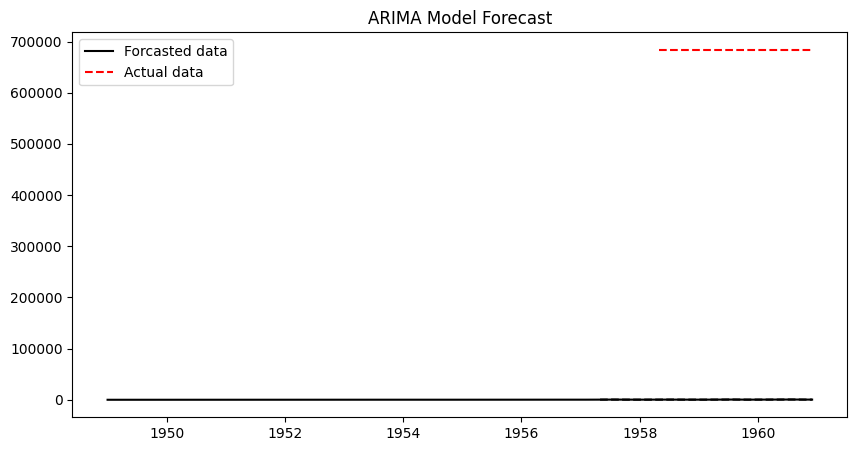

In [219]:
predict_dt = pd.DataFrame(test_predict, index=test.index[12:], columns=test.columns)
forecast_dt = pd.concat([train, predict_dt])

original_data = csv_data.copy()

print(forecast_dt.shape, original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data", color="black")
plt.plot(predict_dt.index, predict_dt["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
plt.plot(test.index, test["n_passengers"], label="Forcasted Data", linestyle="--", color="black")
plt.legend(["Forcasted data", "Actual data"])
plt.title("ARIMA Model Forecast")
plt.show()

In [221]:
test_predict

array([[683833.1 ],
       [683833.1 ],
       [683833.1 ],
       [683833.1 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.2 ],
       [683833.25],
       [683833.25],
       [683833.25],
       [683833.3 ],
       [683833.3 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.4 ],
       [683833.44],
       [683833.44],
       [683833.5 ],
       [683833.5 ],
       [683833.5 ],
       [683833.5 ],
       [683833.5 ]], dtype=float32)